<a href="https://colab.research.google.com/github/Arczisork/Sztuczna-inteligencja/blob/main/sztuczna_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
print(tf.__version__)



2.19.0


In [17]:
observations = 200000
xs = np.random.uniform(low=-10,high=10,size=(observations,1))
zs = np.random.uniform(low=-10,high=10,size=(observations,1))
inputs=np.column_stack((xs,zs))
print(inputs.shape)


(200000, 2)


In [18]:
noise = np.random.uniform(low=-1,high=1,size=(observations,1))
targets = 2*xs - 3*xs + 5 + noise
np.savez('TF_dataset',inputs=inputs,targets=targets)
print(targets.shape)


(200000, 1)


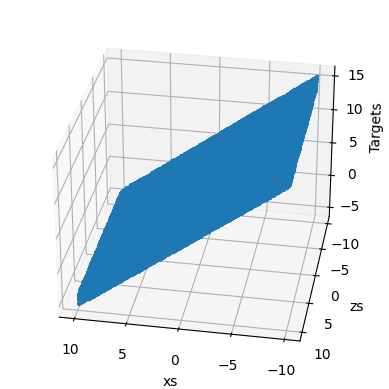

In [19]:

targets = targets.reshape(observations,)
xs = xs.reshape(observations,)
zs = zs.reshape(observations,)
fig = plt.figure()
ax = fig.add_subplot(111,projection='3d')
ax.plot(xs,zs,targets)
ax.set_xlabel('xs')
ax.set_ylabel('zs')
ax.set_zlabel('Targets')
ax.view_init(azim=100)
plt.show()

In [20]:
init_range= 0.1
weights = np.random.uniform(low=-init_range,high=init_range,size=(2,1))
biases = np.random.uniform(low=-init_range,high=init_range,size=1)
print(weights,biases)


[[ 0.07508851]
 [-0.08988159]] [0.00211279]


In [21]:
targets = targets.reshape(observations,1)
eta = 0.001
for i in range (100):
  outputs = np.dot(inputs,weights) + biases
  deltas = outputs - targets

  loss = np.sum(deltas **2)/2/observations
  print(loss)

  deltas_scaled = deltas/observations
  weights = weights - eta * np.dot(inputs.T,deltas_scaled)
  biases = biases - eta * np.sum(deltas_scaled)


32.018993268262314
30.72303774311943
29.510549014123104
28.37605222557387
27.3144318375225
26.32090804338085
25.39101473528016
24.520578915595653
23.70570145972352
22.94273914142524
22.22828783787494
21.559166836984307
20.932404174660615
20.34522293440188
19.795028446069466
19.27939632482376
18.796061295081675
18.34290674797383
17.9179549841608
17.519358097027094
17.14538945422413
16.794435738291455
16.46498950966324
16.155642257775078
15.865077908236179
15.59206675613504
15.335459797510508
15.094183432856253
14.867234518241435
14.653675741233158
14.452631300303302
14.26328286780179
14.08486581788532
13.916665702012189
13.758014955755105
13.608289821750198
13.466907474596992
13.333323334454974
13.207028556952276
13.087547687834988
12.974436471544827
12.867279803622704
12.76568981749865
12.669304096848172
12.577784005273946
12.490813125612569
12.408095801671609
12.329355775674259
12.254334915130185
12.18279202326345
12.114501727513428
12.049253440984902
11.986850392059303
11.92710871769

In [22]:
print(weights, biases)

[[-0.96271974]
 [-0.00509833]] [0.47762391]


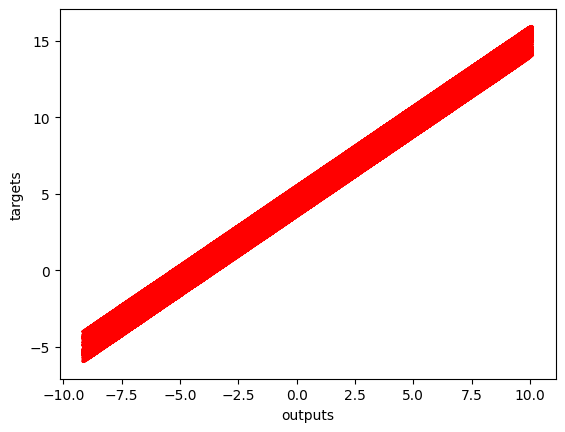

In [23]:
plt.plot(outputs, targets, color='red')
plt.xlabel('outputs')
plt.ylabel('targets')
plt.show()